# Clima

This notebook reads the EPW weather file and analyzes the air temperature series.

The simplest option here is `pvlib.iotools.read_epw`, which returns a pandas DataFrame plus metadata.

You can use the `temp_air` column for temperature analysis.

In [1]:
from pvlib.iotools import read_epw

path = '../epw/MEX_CMX_Cuidad.Mexico.Central.766800_TMYx.2011-2025.epw'
weather, metadata = read_epw(path)

print('Location:', metadata.get('city'), metadata.get('country'))
print('Latitude / longitude:', metadata.get('latitude'), metadata.get('longitude'))
print('Rows:', len(weather))
print('\nTemperature summary (°C):')
print(weather['temp_air'].describe().to_string())

monthly_mean = weather['temp_air'].groupby(weather.index.month).mean()
print('\nMonthly mean temperature (°C):')
print(monthly_mean.to_string())

Location: Cuidad.Mexico.Central MEX
Latitude / longitude: 19.4 -99.183
Rows: 8760

Temperature summary (°C):
count    8760.000000
mean       16.007568
std         5.551997
min         0.100000
25%        11.900000
50%        15.800000
75%        20.300000
max        31.600000

Monthly mean temperature (°C):
1     12.207796
2     14.668601
3     16.932661
4     18.311389
5     18.702823
6     17.931389
7     17.199597
8     16.914785
9     16.882222
10    15.535081
11    13.857639
12    12.912500


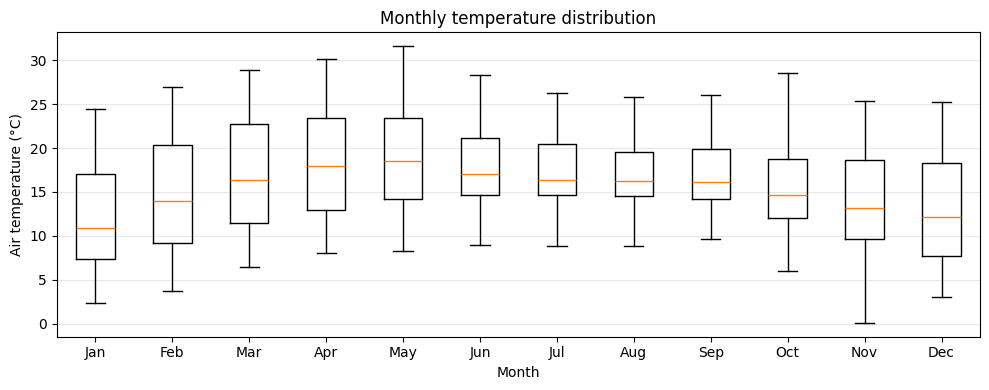

In [3]:
import calendar
import matplotlib.pyplot as plt

month_labels = [calendar.month_abbr[m] for m in range(1, 13)]
monthly_temperature = [weather.loc[weather.index.month == month, 'temp_air'] for month in range(1, 13)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(monthly_temperature, tick_labels=month_labels, showfliers=False)
ax.set_xlabel('Month')
ax.set_ylabel('Air temperature (°C)')
ax.set_title('Monthly temperature distribution')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

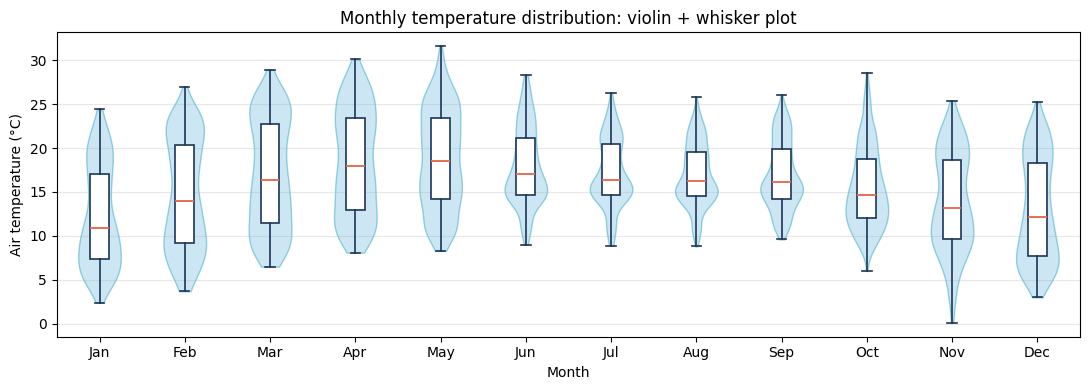

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
positions = range(1, 13)

violins = ax.violinplot(
    monthly_temperature,
    positions=positions,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)
for body in violins['bodies']:
    body.set_facecolor('#8ecae6')
    body.set_edgecolor('#219ebc')
    body.set_alpha(0.45)

ax.boxplot(
    monthly_temperature,
    positions=positions,
    widths=0.22,
    patch_artist=True,
    showfliers=True,
    boxprops={'facecolor': 'white', 'edgecolor': '#1d3557', 'linewidth': 1.2},
    whiskerprops={'color': '#1d3557', 'linewidth': 1.2},
    capprops={'color': '#1d3557', 'linewidth': 1.2},
    medianprops={'color': '#e76f51', 'linewidth': 1.4},
    flierprops={'marker': 'o', 'markerfacecolor': '#d62828', 'markeredgecolor': '#d62828', 'markersize': 4, 'alpha': 0.8},
)

ax.set_xticks(list(positions))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Air temperature (°C)')
ax.set_title('Monthly temperature distribution: violin + whisker plot')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

hdd_base_f = 65
cdd_base_f = 50
hdd_base_c = (hdd_base_f - 32) * 5 / 9
cdd_base_c = (cdd_base_f - 32) * 5 / 9

daily_mean = weather['temp_air'].resample('D').mean()

month_stats = pd.DataFrame({
    'mean_temp': weather['temp_air'].groupby(weather.index.month).mean(),
    'min_temp': weather['temp_air'].groupby(weather.index.month).min(),
    'max_temp': weather['temp_air'].groupby(weather.index.month).max(),
})
month_stats.index = [month_labels[i - 1] for i in month_stats.index]
month_stats['HDD18.3'] = (hdd_base_c - daily_mean).clip(lower=0).groupby(daily_mean.index.month).sum().values
month_stats['CDD10'] = (daily_mean - cdd_base_c).clip(lower=0).groupby(daily_mean.index.month).sum().values

month_stats = month_stats.round(2)
print(month_stats)
print()
print(f'Los Grados Día de Calefacción Anual base {hdd_base_c:.1f} °C (equivalente a {hdd_base_f} °F) reportados por CONUEE son 2351, y los Grados Día de Refrigeración Anual base {cdd_base_c:.0f} °C (equivalente a {cdd_base_f} °F) son 4959.')
print('Esto coincide con el análisis mensual que se muestra abajo, donde enero es el mes crítico frío y mayo es el mes crítico cálido.')

     mean_temp  min_temp  max_temp  HDD18.3   CDD10
Jan      12.21       2.4      24.4   189.89   68.44
Feb      14.67       3.7      27.0   102.61  130.72
Mar      16.93       6.5      28.9    45.67  214.91
Apr      18.31       8.1      30.1    21.98  249.34
May      18.70       8.3      31.6    16.87  269.79
Jun      17.93       9.0      28.3    26.30  237.94
Jul      17.20       8.9      26.3    35.22  223.19
Aug      16.91       8.8      25.8    44.30  214.36
Sep      16.88       9.6      26.0    43.64  206.47
Oct      15.54       6.0      28.6    86.75  171.59
Nov      13.86       0.1      25.4   134.27  119.68
Dec      12.91       3.0      25.2   168.05   90.78

Los Grados Día de Calefacción Anual base 18.3 °C (equivalente a 65 °F) reportados por CONUEE son 2351, y los Grados Día de Refrigeración Anual base 10 °C (equivalente a 50 °F) son 4959.
Esto coincide con el análisis mensual que se muestra abajo, donde enero es el mes crítico frío y mayo es el mes crítico cálido.


## Interpretation

Using the EPW monthly temperature statistics and degree-days with separate bases of 18.3 °C for heating and 10 °C for cooling:

- **Critical cold month:** **January**. It has the lowest mean temperature (12.21 °C) and the highest heating degree-days (HDD18.3 = 189.89).
- **Critical hot month:** **May**. It has the highest mean temperature (18.70 °C), the highest maximum temperature (31.6 °C), and the highest cooling degree-days (CDD10 = 269.79).
- **Secondary cold period:** **November to December**, which also show low mean temperatures and large HDD values.
- **Secondary warm period:** **April to June**, especially April and May, where both mean temperature and CDD rise sharply.

Bioclimatic conclusion: the design priority is to support **winter comfort and solar gain in the cold season** and **shading / overheating control in late spring and early summer**.

In [10]:
import pandas as pd
from pvlib.iotools import read_epw
f = "../epw/MEX_CMX_Cuidad.Mexico.Central.766800_TMYx.2011-2025.epw"
weather, metadata = read_epw(f)

gdc_base_f = 65
gdr_base_f = 50
hdd_base_c = (hdd_base_f - 32) * 5 / 9
gdr_base_c = (gdr_base_f - 32) * 5 / 9

media_diaria = weather['temp_air'].resample('D').mean()

estadisticas_mensuales = pd.DataFrame({
    'temp_media': weather['temp_air'].groupby(weather.index.month).mean(),
    'temp_min': weather['temp_air'].groupby(weather.index.month).min(),
    'temp_max': weather['temp_air'].groupby(weather.index.month).max(),
})
meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
estadisticas_mensuales.index = [meses_es[i - 1] for i in estadisticas_mensuales.index]
estadisticas_mensuales['GDCA18.3'] = (hdd_base_c - media_diaria).clip(lower=0).groupby(media_diaria.index.month).sum().values
estadisticas_mensuales['GDRA10'] = (media_diaria - gdr_base_c).clip(lower=0).groupby(media_diaria.index.month).sum().values
estadisticas_mensuales = estadisticas_mensuales.round(2)
print(estadisticas_mensuales)

     temp_media  temp_min  temp_max  GDCA18.3  GDRA10
Ene       12.21       2.4      24.4    189.89   68.44
Feb       14.67       3.7      27.0    102.61  130.72
Mar       16.93       6.5      28.9     45.67  214.91
Abr       18.31       8.1      30.1     21.98  249.34
May       18.70       8.3      31.6     16.87  269.79
Jun       17.93       9.0      28.3     26.30  237.94
Jul       17.20       8.9      26.3     35.22  223.19
Ago       16.91       8.8      25.8     44.30  214.36
Sep       16.88       9.6      26.0     43.64  206.47
Oct       15.54       6.0      28.6     86.75  171.59
Nov       13.86       0.1      25.4    134.27  119.68
Dic       12.91       3.0      25.2    168.05   90.78
